In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             ConfusionMatrixDisplay, classification_report, roc_curve, auc)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_style('darkgrid')

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
df_train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')

print(df_train.info())
print(df_train.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.48659

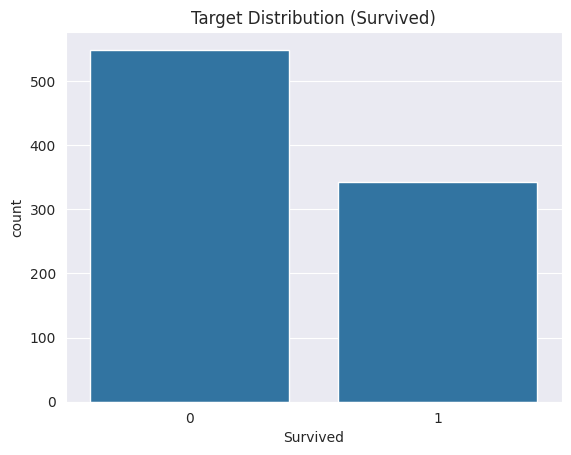

In [3]:
sns.countplot(x='Survived', data=df_train)
plt.title('Target Distribution (Survived)')
plt.show()

In [4]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df_train[features]
y = df_train['Survived']

numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Sex', 'Embarked', 'Pclass'] 

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

In [5]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_val)
y_pred_proba = model_pipeline.predict_proba(X_val)[:, 1]

In [6]:
print(f"Accuracy  : {accuracy_score(y_val, y_pred):.4f}")
print(f"Precision : {precision_score(y_val, y_pred):.4f}")
print(f"Recall    : {recall_score(y_val, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_val, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_val, y_pred_proba):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_val, y_pred))

Accuracy  : 0.8060
Precision : 0.7980
Recall    : 0.7117
F1-Score  : 0.7524
ROC-AUC   : 0.8721

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       157
           1       0.80      0.71      0.75       111

    accuracy                           0.81       268
   macro avg       0.80      0.79      0.80       268
weighted avg       0.81      0.81      0.80       268



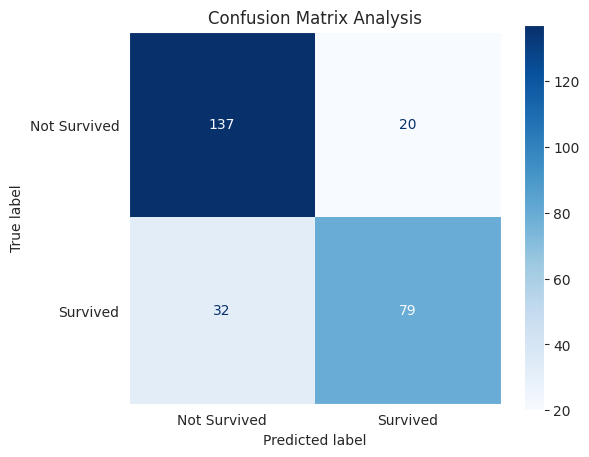

Detailed Analysis of Confusion Matrix:
- True Positives (TP) : 79 (Correctly predicted as Survived)
- True Negatives (TN) : 137 (Correctly predicted as Not Survived)
- False Positives (FP): 20 (Incorrectly predicted as Survived - Type I Error)
- False Negatives (FN): 32 (Incorrectly predicted as Not Survived - Type II Error)


In [7]:
cm = confusion_matrix(y_val, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix Analysis')
plt.grid(False)
plt.show()

print("Detailed Analysis of Confusion Matrix:")
print(f"- True Positives (TP) : {tp} (Correctly predicted as Survived)")
print(f"- True Negatives (TN) : {tn} (Correctly predicted as Not Survived)")
print(f"- False Positives (FP): {fp} (Incorrectly predicted as Survived - Type I Error)")
print(f"- False Negatives (FN): {fn} (Incorrectly predicted as Not Survived - Type II Error)")

In [8]:
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(14, 5))

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

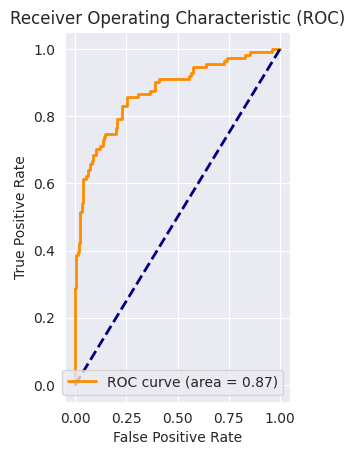

In [9]:
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")

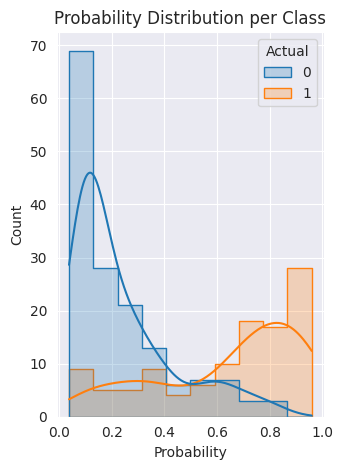

In [10]:
plt.subplot(1, 2, 2)
df_prob = pd.DataFrame({'Probability': y_pred_proba, 'Actual': y_val})
sns.histplot(data=df_prob, x='Probability', hue='Actual', element='step', kde=True)
plt.title('Probability Distribution per Class')

plt.tight_layout()
plt.show()